<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan5_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 5 — Visualisasi Data
## Dashboard Visualisasi Statis: Dataset Penguins

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Pengantar Data Science (200302305) |
| **Pertemuan** | 5 — Visualisasi Data |


## Langkah 1 — Setup & Inspeksi Dataset

Memuat dataset `penguins`, menetapkan tema global Seaborn, lalu memeriksa struktur dan ringkasan statistik. Dataset ini memuat pengukuran morfologi tiga spesies penguin (Adelie, Chinstrap, Gentoo) dari tiga pulau di Kepulauan Palmer, Antarktika.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = sns.load_dataset('penguins')
print('Shape:', df.shape)
print()
print(df.dtypes)
print()
print('Jumlah missing value per kolom:')
print(df.isna().sum())

Shape: (344, 7)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Jumlah missing value per kolom:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [2]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Bersihkan baris dengan nilai kosong untuk analisis numerik
df_clean = df.dropna().reset_index(drop=True)
print('Setelah dropna:', df_clean.shape)
df_clean.describe().round(2)

Setelah dropna: (333, 7)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06
std,5.47,1.97,14.02,805.22
min,32.10,13.10,172.00,2700.00
25%,39.50,15.60,190.00,3550.00
50%,44.50,17.30,197.00,4050.00
75%,48.60,18.70,213.00,4775.00
max,59.60,21.50,231.00,6300.00


**Interpretasi singkat:** Dataset memiliki 344 baris dan 7 kolom — empat numerik (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) dan tiga kategorik (`species`, `island`, `sex`). Terdapat 19 nilai kosong (terbanyak pada `sex`); setelah `dropna()` tersisa 333 baris bersih yang dipakai untuk seluruh analisis numerik.

## Langkah 2 — Grafik 1: Bar Chart (Rata-rata Massa Tubuh per Spesies)

Bar chart membandingkan nilai diskret antar kategori. Sumbu dimulai dari nol agar perbandingan tidak menyesatkan (Prinsip Akurasi).

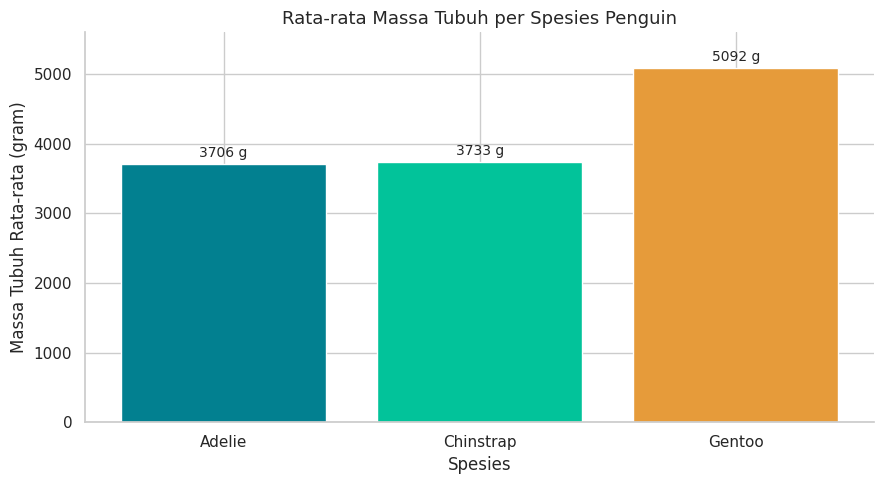

In [4]:
avg_mass = df_clean.groupby('species')['body_mass_g'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_mass.index, avg_mass.values,
              color=['#028090', '#02C39A', '#E69B3A'], edgecolor='white')
ax.bar_label(bars, fmt='%.0f g', padding=3, fontsize=10)
ax.set_title('Rata-rata Massa Tubuh per Spesies Penguin', fontsize=13)
ax.set_xlabel('Spesies')
ax.set_ylabel('Massa Tubuh Rata-rata (gram)')
ax.set_ylim(0, 5600)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What?** Bar chart ini menampilkan rata-rata massa tubuh (gram) untuk tiga spesies penguin dari 333 observasi bersih. Adelie ≈ 3.701 g dan Chinstrap ≈ 3.733 g hampir setara, sedangkan Gentoo jauh lebih berat ≈ 5.076 g.

**So what?** Gentoo rata-rata ~37% lebih berat dari dua spesies lain, menjadikan massa tubuh fitur pembeda yang kuat untuk Gentoo. Sebaliknya Adelie dan Chinstrap nyaris tak terbedakan hanya dari massa tubuh (selisih ~32 g, jauh di bawah standar deviasinya).

**Now what?** Untuk membedakan Adelie vs Chinstrap dibutuhkan fitur lain (mis. `bill_length_mm`). Perlu dieksplorasi apakah perbedaan massa ini murni faktor spesies atau dipengaruhi rasio jenis kelamin pada tiap kelompok.

## Langkah 3 — Grafik 2: Histogram + KDE (Distribusi Massa Tubuh per Spesies)

Histogram dengan kurva KDE memperlihatkan bentuk distribusi satu variabel; parameter `hue` membandingkan tiga spesies sekaligus.

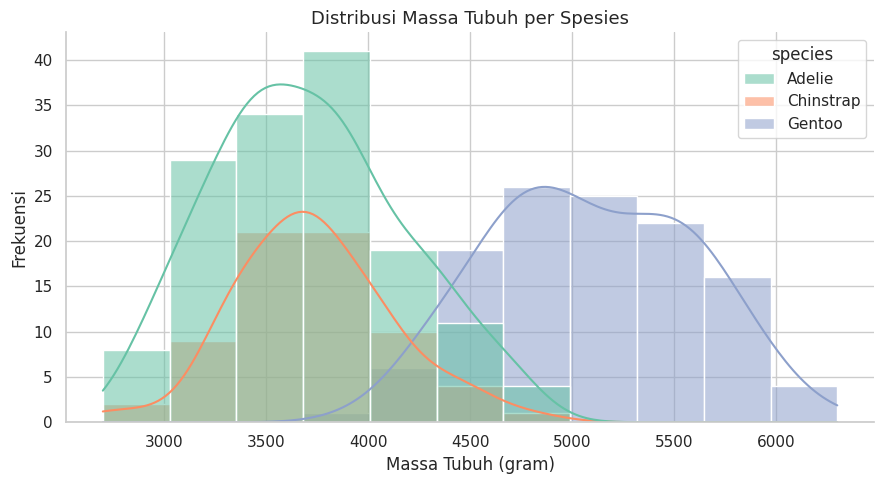

Skewness massa tubuh (keseluruhan): 0.472


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_clean, x='body_mass_g', hue='species',
             kde=True, palette='Set2', alpha=0.55, ax=ax)
ax.set_title('Distribusi Massa Tubuh per Spesies', fontsize=13)
ax.set_xlabel('Massa Tubuh (gram)')
ax.set_ylabel('Frekuensi')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Skewness massa tubuh (keseluruhan):',
      round(df_clean['body_mass_g'].skew(), 3))

**What?** Distribusi massa tubuh keseluruhan bergerak dari ~2.700 g hingga ~6.300 g dengan skewness +0.47 (miring kanan moderat). Terlihat jelas **bimodal**: Adelie dan Chinstrap menumpuk di 3.000–4.500 g, sedangkan Gentoo membentuk puncak terpisah di 4.700–6.000 g.

**So what?** Pola bimodal ini mengonfirmasi temuan bar chart — Gentoo adalah kelompok berat yang terpisah. Kemiringan ke kanan pada distribusi gabungan disebabkan oleh "ekor" Gentoo, bukan oleh outlier individual.

**Now what?** Karena distribusi tidak normal (bimodal), uji statistik yang mengasumsikan normalitas sebaiknya dijalankan per spesies, bukan pada data gabungan. Analisis lanjutan bisa memisahkan distribusi berdasarkan jenis kelamin di dalam tiap spesies.

## Langkah 4 — Grafik 3: Boxplot (Panjang Flipper per Spesies)

Boxplot meringkas lima statistik (min, Q1, median, Q3, max) dan menyoroti outlier — sangat efektif membandingkan distribusi antar kelompok.

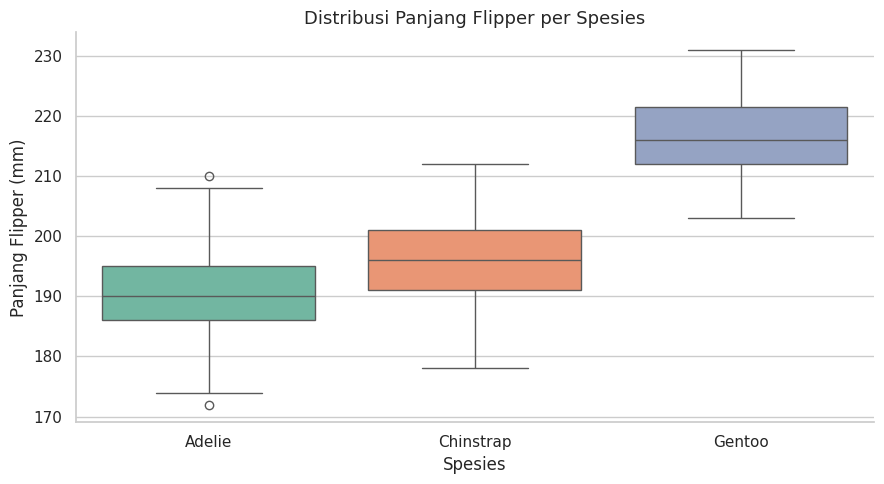

             min  median    max  std
species                             
Adelie     172.0   190.0  210.0  6.5
Chinstrap  178.0   196.0  212.0  7.1
Gentoo     203.0   216.0  231.0  6.6


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x='species', y='flipper_length_mm',
            hue='species', palette='Set2', legend=False, ax=ax)
ax.set_title('Distribusi Panjang Flipper per Spesies', fontsize=13)
ax.set_xlabel('Spesies')
ax.set_ylabel('Panjang Flipper (mm)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(df_clean.groupby('species')['flipper_length_mm']
      .agg(['min', 'median', 'max', 'std']).round(1))

**What?** Boxplot menampilkan panjang flipper per spesies. Median naik berurutan: Adelie ≈ 190 mm, Chinstrap ≈ 196 mm, dan Gentoo ≈ 216 mm (rentang 203–231 mm). Kotak Gentoo terpisah hampir sepenuhnya dari dua spesies lain.

**So what?** Panjang flipper adalah pembeda spesies yang sangat baik, terutama untuk mengisolasi Gentoo. Adelie dan Chinstrap masih tumpang tindih, tetapi Chinstrap konsisten sedikit lebih panjang. Sebaran (IQR) ketiga spesies relatif serupa, menandakan variabilitas internal yang sebanding.

**Now what?** Kombinasi panjang flipper + massa tubuh dapat dijadikan dasar model klasifikasi spesies sederhana. Perlu dicek apakah flipper yang lebih panjang berkorelasi dengan massa tubuh yang lebih besar (dieksplorasi di grafik scatter).

## Langkah 5 — Grafik 4: Scatter Plot (Panjang Flipper vs Massa Tubuh)

Scatter plot mengungkap hubungan dua variabel numerik. `hue` menambah dimensi spesies dan garis regresi menunjukkan tren keseluruhan.

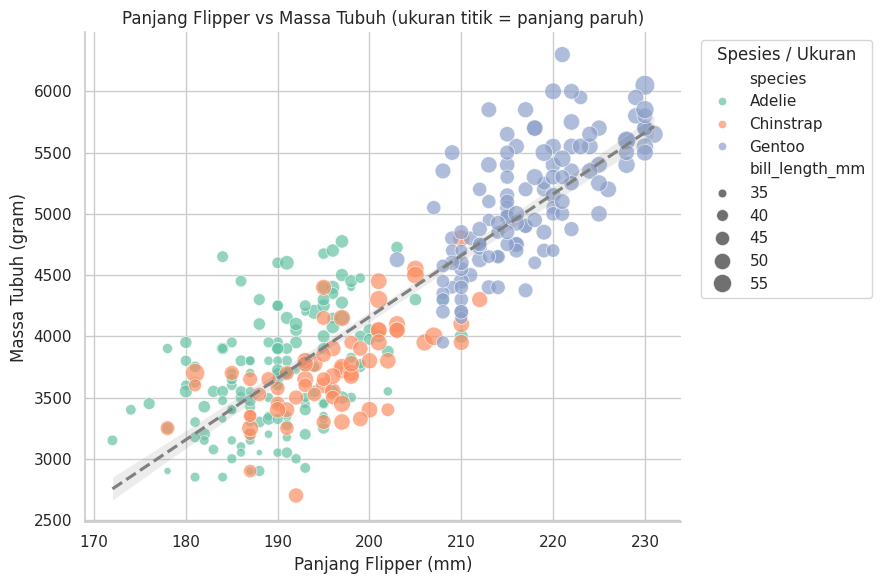

Korelasi Pearson flipper vs massa tubuh: r = 0.873


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_clean, x='flipper_length_mm', y='body_mass_g',
                hue='species', size='bill_length_mm', sizes=(20, 200),
                palette='Set2', alpha=0.7, ax=ax)
sns.regplot(data=df_clean, x='flipper_length_mm', y='body_mass_g',
            scatter=False, color='gray',
            line_kws={'linestyle': '--'}, ax=ax)
ax.set_title('Panjang Flipper vs Massa Tubuh (ukuran titik = panjang paruh)',
             fontsize=12)
ax.set_xlabel('Panjang Flipper (mm)')
ax.set_ylabel('Massa Tubuh (gram)')
ax.legend(title='Spesies / Ukuran', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

r = df_clean['flipper_length_mm'].corr(df_clean['body_mass_g'])
print(f'Korelasi Pearson flipper vs massa tubuh: r = {r:.3f}')

**What?** Scatter plot menunjukkan hubungan **linear positif sangat kuat** antara panjang flipper dan massa tubuh (r = 0.873): semakin panjang flipper, semakin berat penguin. Tiga spesies membentuk klaster berurutan, dengan Gentoo (titik besar) berada di kanan atas.

**So what?** Korelasi 0.87 tergolong "kuat" menurut tabel interpretasi — flipper dan massa tubuh tumbuh bersama, kemungkinan mencerminkan ukuran tubuh keseluruhan. Klaster yang rapi per spesies menegaskan bahwa dua fitur ini saja sudah memisahkan ketiga spesies dengan baik.

**Now what?** Korelasi kuat ini ideal sebagai fitur model prediksi massa/spesies, tetapi perlu diingat **korelasi bukan kausalitas** — keduanya kemungkinan dipengaruhi variabel ketiga (ukuran/spesies). Langkah lanjutan: bangun model klasifikasi dan uji akurasinya pada data uji terpisah.

## Langkah 6 — Dashboard Gabungan 2×2

Keempat grafik dirangkai dalam satu kanvas menggunakan `GridSpec`, lalu diekspor sebagai PNG beresolusi tinggi (dashboard visualisasi statis).

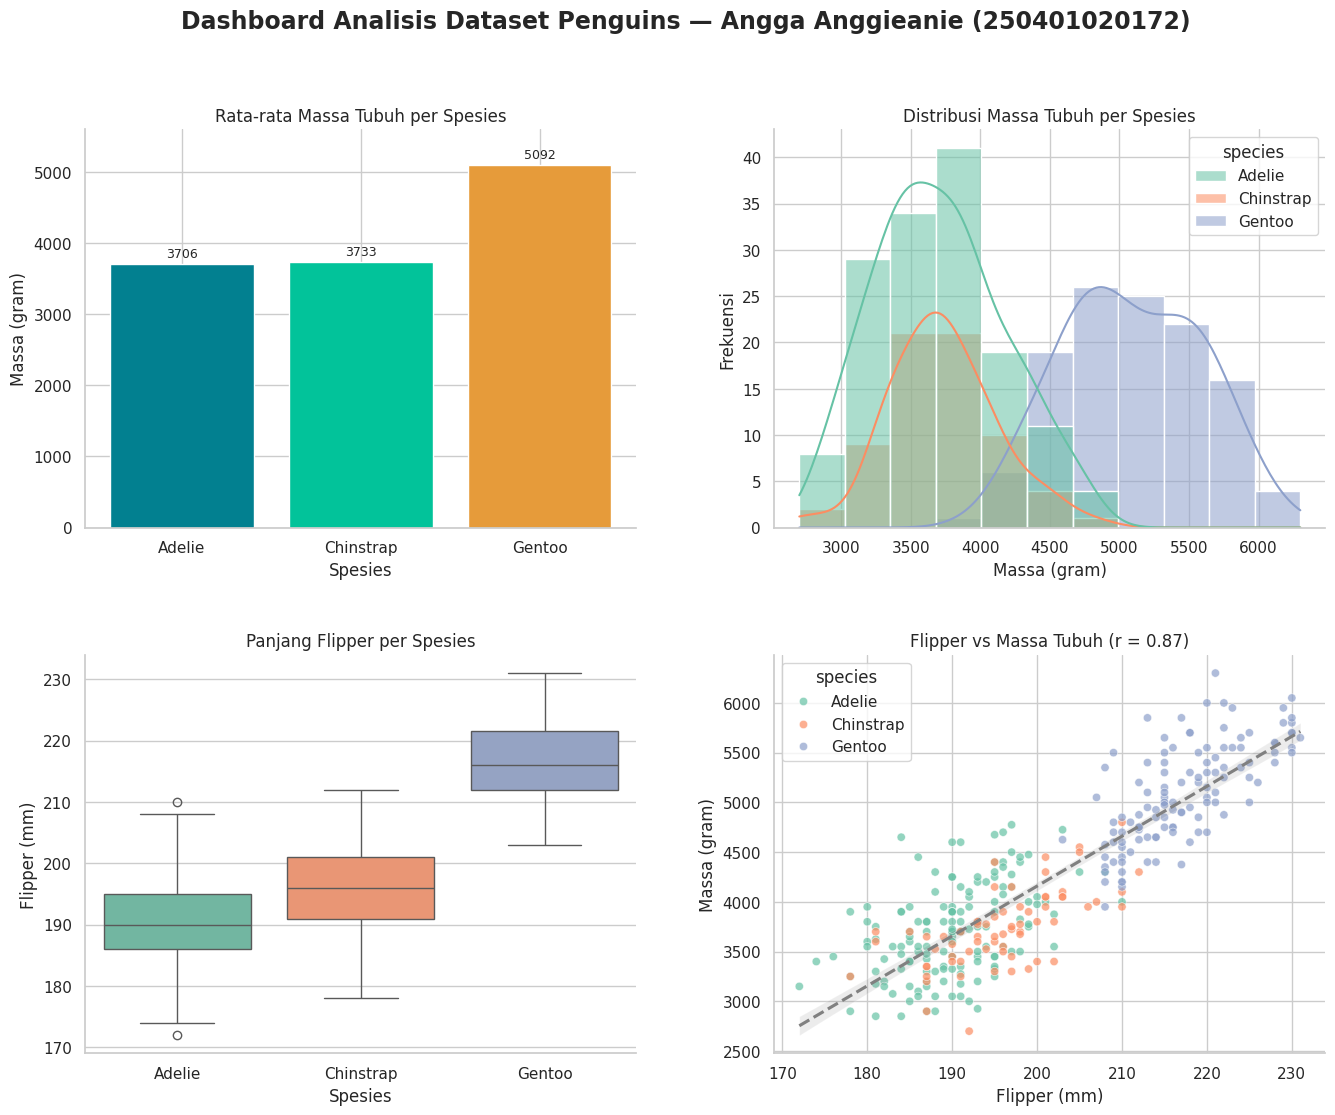

Dashboard tersimpan sebagai dashboard_penguins.png


In [8]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Penguins — Angga Anggieanie (250401020172)',
             fontsize=17, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.32, wspace=0.25)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. Bar chart
bars = ax1.bar(avg_mass.index, avg_mass.values,
               color=['#028090', '#02C39A', '#E69B3A'], edgecolor='white')
ax1.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax1.set_title('Rata-rata Massa Tubuh per Spesies')
ax1.set_xlabel('Spesies'); ax1.set_ylabel('Massa (gram)')
ax1.set_ylim(0, 5600)
ax1.spines[['top', 'right']].set_visible(False)

# 2. Histogram + KDE
sns.histplot(data=df_clean, x='body_mass_g', hue='species',
             kde=True, palette='Set2', alpha=0.55, ax=ax2)
ax2.set_title('Distribusi Massa Tubuh per Spesies')
ax2.set_xlabel('Massa (gram)'); ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)

# 3. Boxplot
sns.boxplot(data=df_clean, x='species', y='flipper_length_mm',
            hue='species', palette='Set2', legend=False, ax=ax3)
ax3.set_title('Panjang Flipper per Spesies')
ax3.set_xlabel('Spesies'); ax3.set_ylabel('Flipper (mm)')
ax3.spines[['top', 'right']].set_visible(False)

# 4. Scatter
sns.scatterplot(data=df_clean, x='flipper_length_mm', y='body_mass_g',
                hue='species', palette='Set2', alpha=0.7, ax=ax4, legend=True)
sns.regplot(data=df_clean, x='flipper_length_mm', y='body_mass_g',
            scatter=False, color='gray',
            line_kws={'linestyle': '--'}, ax=ax4)
ax4.set_title('Flipper vs Massa Tubuh (r = 0.87)')
ax4.set_xlabel('Flipper (mm)'); ax4.set_ylabel('Massa (gram)')
ax4.spines[['top', 'right']].set_visible(False)

plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_penguins.png')

## Langkah 7 — Eksplorasi Tambahan: Pair Plot

Pair plot menghasilkan matriks scatter untuk semua pasangan variabel numerik sekaligus — berguna untuk melihat seluruh hubungan dalam satu pandangan.

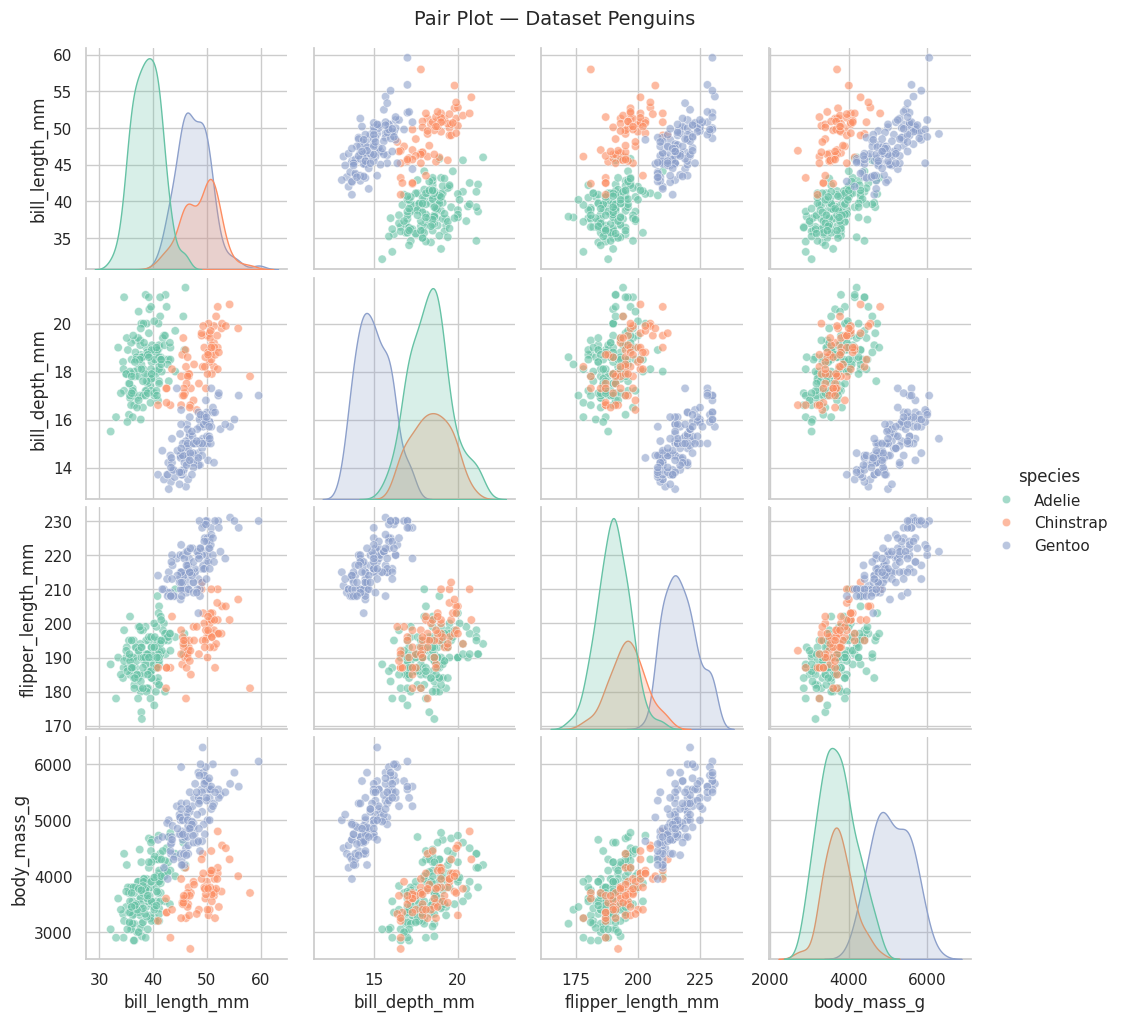

In [9]:
pair = sns.pairplot(df_clean, hue='species', palette='Set2',
                    diag_kind='kde', plot_kws={'alpha': 0.6})
pair.fig.suptitle('Pair Plot — Dataset Penguins', y=1.02, fontsize=14)
plt.show()

**What? / So what? / Now what?:** Pair plot menampilkan keenam kombinasi variabel numerik. Pasangan `flipper_length_mm` × `body_mass_g` memperlihatkan klaster spesies paling rapi, sedangkan `bill_length_mm` × `bill_depth_mm` menunjukkan **paradoks Simpson** menarik: secara gabungan korelasinya tampak negatif, tetapi dalam tiap spesies justru positif. Temuan ini menegaskan pentingnya menganalisis per kelompok, bukan hanya agregat — dan menjadi agenda eksplorasi lanjutan untuk model klasifikasi spesies.

## Kesimpulan

Dashboard ini mengungkap bahwa **Gentoo adalah spesies yang paling mudah dibedakan** — paling berat (~5.076 g) dan berflipper paling panjang (median ~216 mm), terpisah jelas pada bar chart, histogram, maupun boxplot. **Adelie dan Chinstrap serupa dalam massa tubuh** sehingga memerlukan fitur tambahan seperti panjang paruh untuk dipisahkan. Hubungan panjang flipper dan massa tubuh sangat kuat (r = 0.87), menjadikan keduanya fitur utama yang efektif untuk klasifikasi spesies. Sesuai prinsip visualisasi efektif, setiap grafik menggunakan judul deskriptif, label sumbu bersatuan, palet warna konsisten yang ramah buta warna, sumbu bar mulai dari nol, dan border yang diminimalkan (high data-ink ratio).